# Microgrid siting pilot: Ntabankulu

Visual walk-through of a single-ward pilot: where the buildings are, which of them count
as far from the grid, the candidate sites (one qubit each), and the QUBO the quantum
solver will work on.

Change the config in the next cell and re-run everything. The first run pulls Overture
buildings for the whole municipality (about 3 minutes); after that it reads the local cache.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np

from quackathon.classical import solve_exact, solve_qubo_brute_force
from quackathon.config import PilotConfig
from quackathon.grid import load_grid
from quackathon.overture import fetch_building_centroids
from quackathon.pipeline import build_pilot
from quackathon.quantum import dicke_state, qaoa_circuit, qaoa_depth_sweep, qubo_to_ising
from quackathon.region import load_wards
from quackathon import viz

viz.use_style()
%config InlineBackend.figure_format = "retina"

In [2]:
cfg = PilotConfig(
    ward_no=19,
    grid_distance_m=2_000,   # demand focus: only settlements beyond this distance from the grid
    n_sites=3,               # microgrids to build
    n_candidates=12,         # candidate sites = qubits
    service_radius_m=1_500,  # reach of a microgrid's distribution network
    grid_source="gridfinder",  # OSM + predicted MV grid; "osm" = mapped lines only
)
pilot = build_pilot(cfg)
p = pilot.problem
print(f"{len(pilot.buildings):,} buildings -> {len(pilot.all_nodes)} demand nodes, "
      f"{len(pilot.nodes)} beyond {cfg.grid_distance_m:,.0f} m of grid ({p.demand.sum():.0f} kWh/day)")
print(f"{p.n_sites} candidate sites (qubits), choose {p.n_select}")

8,346 buildings -> 162 demand nodes, 69 beyond 2,000 m of grid (271 kWh/day)
12 candidate sites (qubits), choose 3


## 1. The municipality

Buildings per ward (Overture: Google, Microsoft and OSM footprints) and the grid.
Solid lines are mapped in OSM; dashed lines are gridfinder's predicted medium-voltage
network (Arderne et al. 2020), which fills in the distribution lines OSM is missing.
Gridfinder is a model built from night-time lights and roads, so treat the predicted
lines as an estimate.

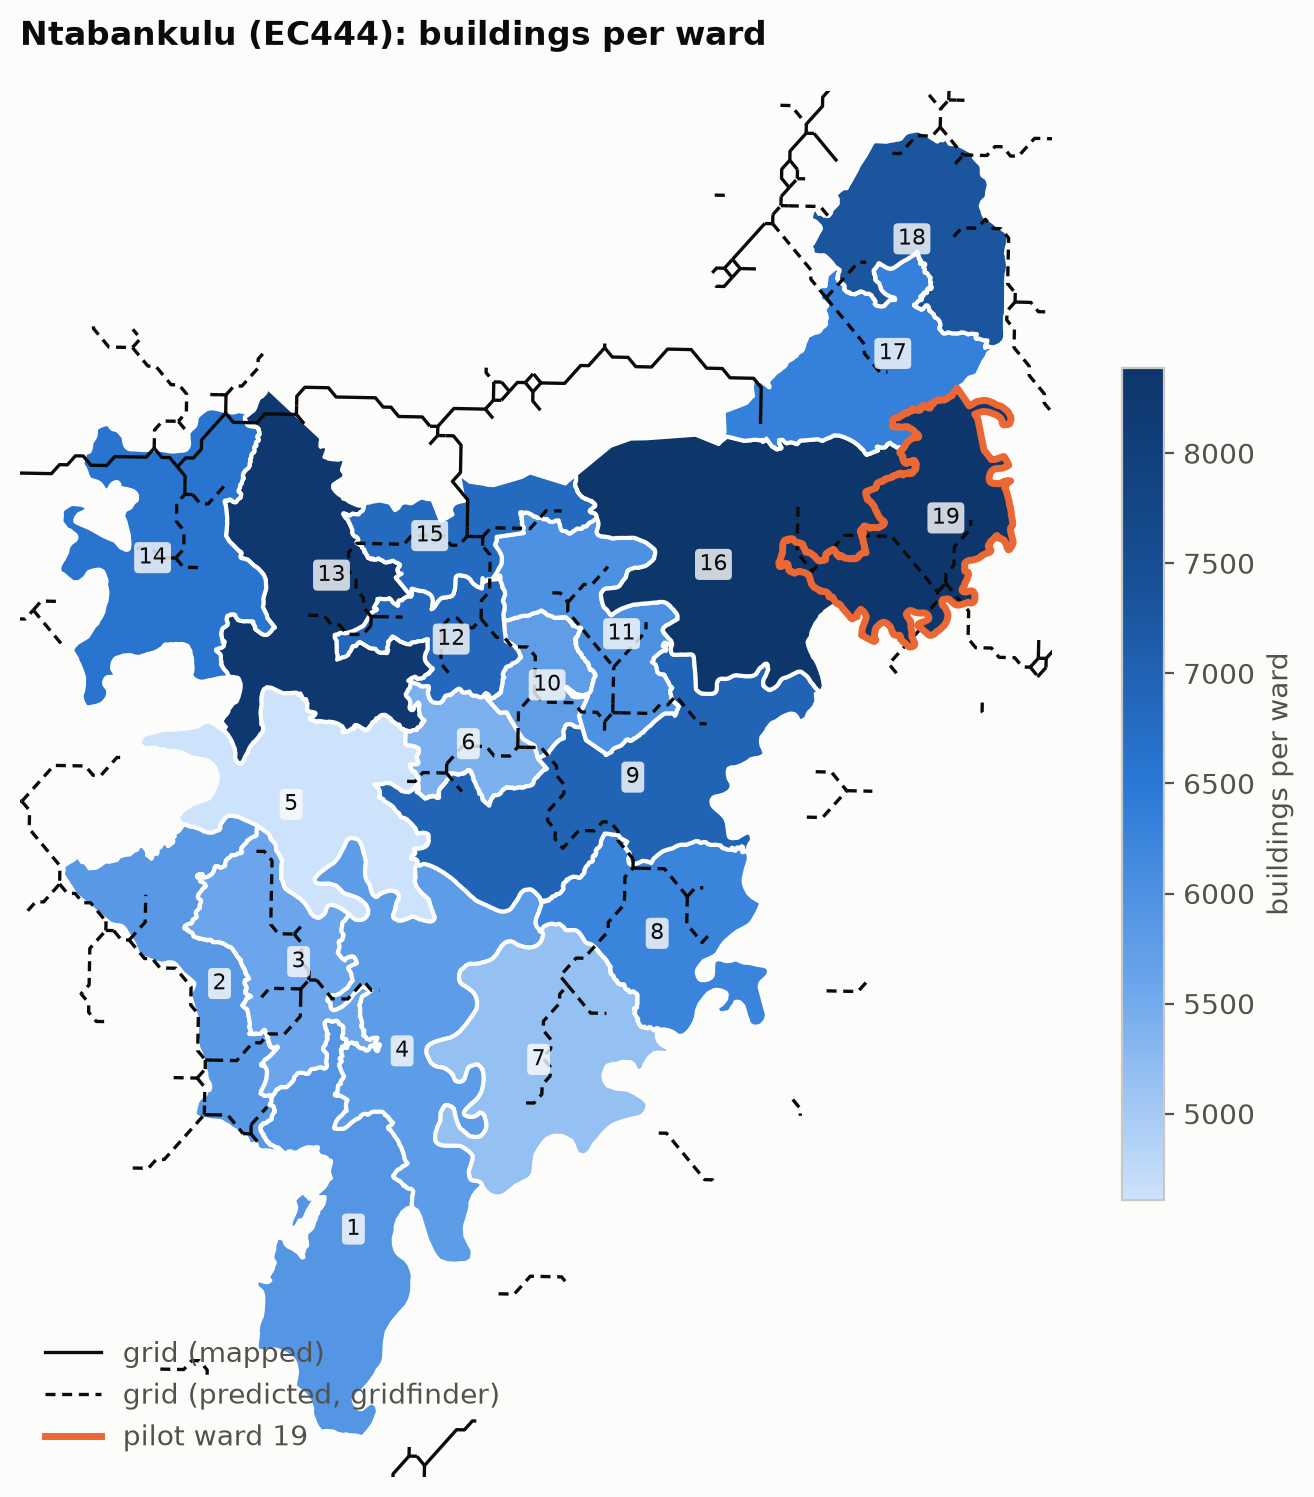

In [3]:
wards = load_wards(cfg)
all_buildings = fetch_building_centroids(wards, cfg.raw_dir)
municipal_grid = load_grid(wards, cfg)
viz.plot_municipality(wards, all_buildings, municipal_grid, pilot_ward=cfg.ward_no)
plt.show()

## 2. Who counts as far from the grid

`grid_distance_m` cuts the ward's buildings into the ones we ignore (assumed to be
served by grid extension) and the ones that become microgrid demand.

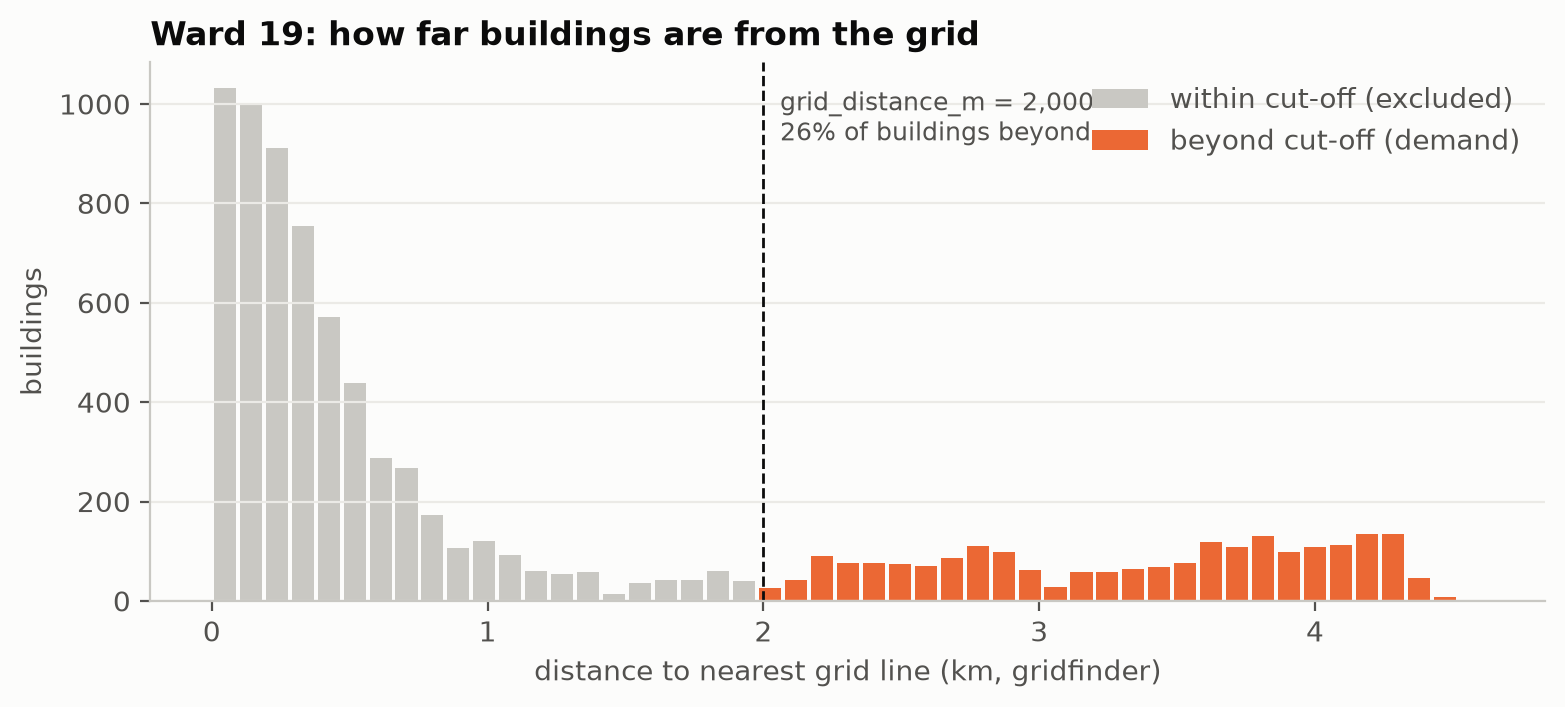

In [4]:
viz.plot_grid_distance(pilot)
plt.show()

## 3. Candidate sites and the optimal selection

Grey dots are all buildings. Coloured dots are far-from-grid demand nodes (500 m cells,
sized by demand). Triangles are candidate sites, labelled with their qubit index. The
selection shown is the true optimum, found by checking every possible choice of sites.

exact: x=011100000000  served=216.9 kWh/day
QUBO:  x=010100100000  served=216.9 kWh/day  feasible=True


/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


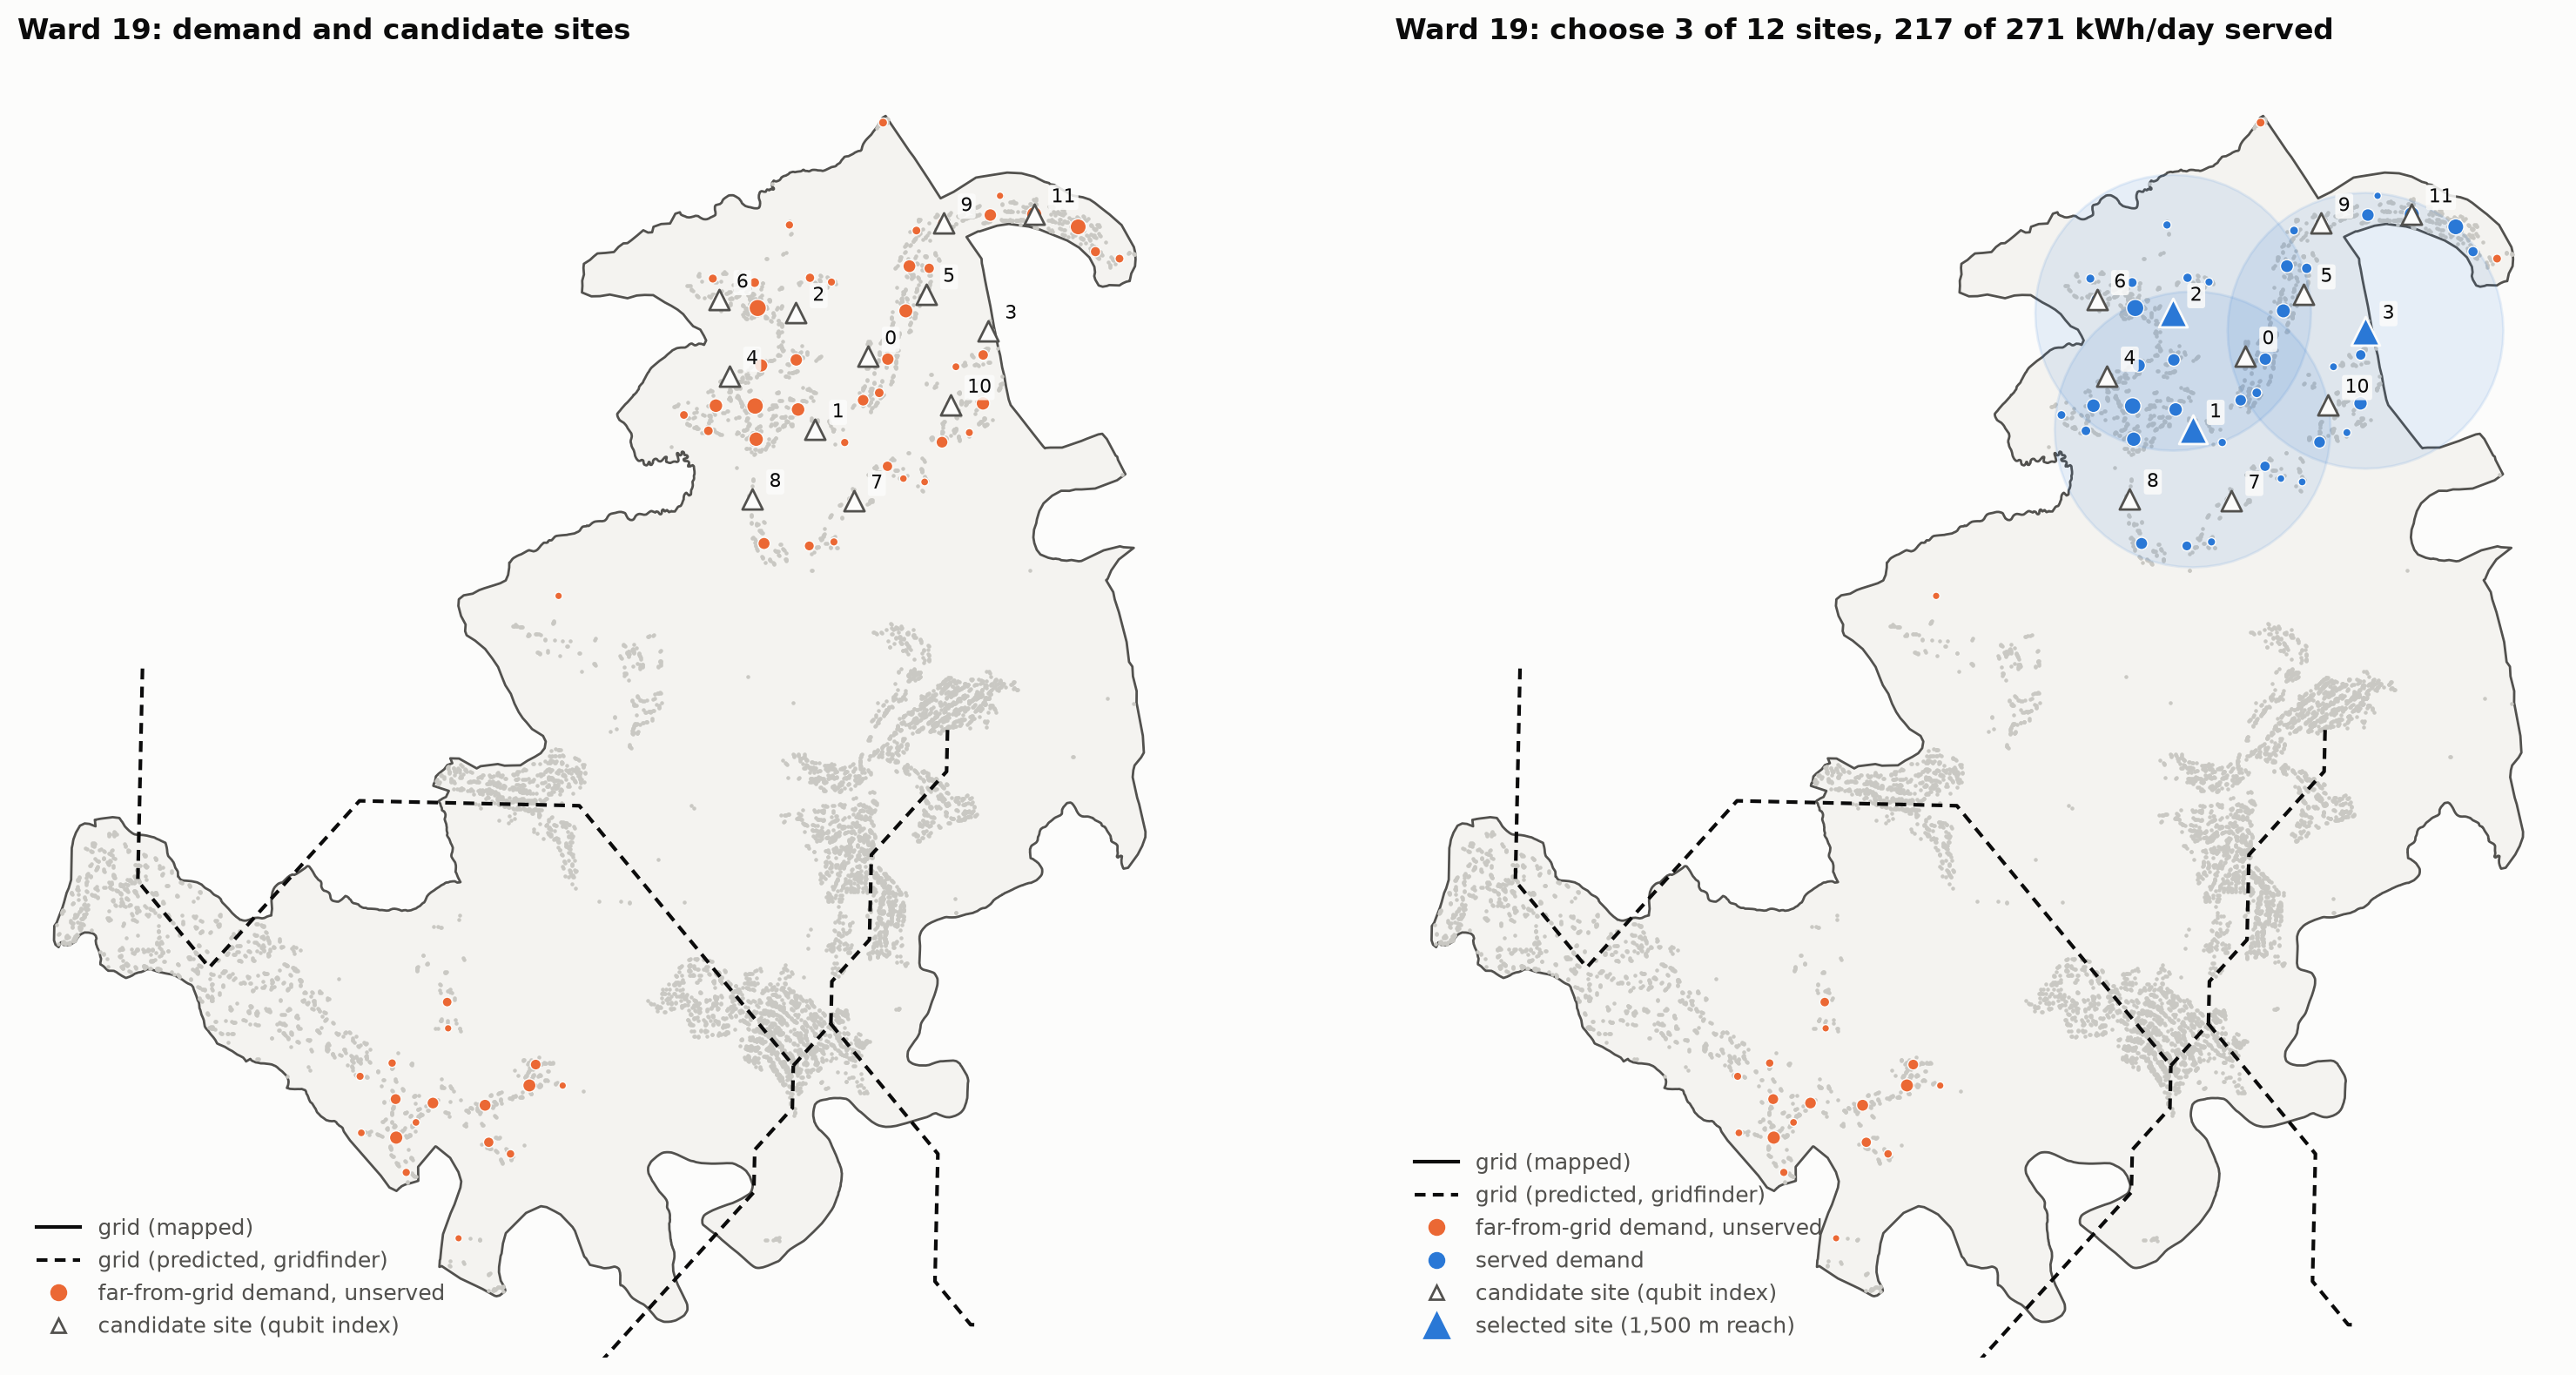

In [5]:
exact = solve_exact(p)
qubo = solve_qubo_brute_force(*p.to_qubo())
print(f"exact: x={''.join(map(str, exact.x))}  served={p.served_demand(exact.x):.1f} kWh/day")
print(f"QUBO:  x={''.join(map(str, qubo.x))}  served={p.served_demand(qubo.x):.1f} kWh/day  "
      f"feasible={p.is_feasible(qubo.x)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
viz.plot_pilot(pilot, ax=axes[0], title=f"Ward {cfg.ward_no}: demand and candidate sites")
viz.plot_pilot(pilot, exact.x, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. The QUBO

**Matrix.** Without the cardinality penalty, the diagonal holds each site's reachable
demand (negative, so choosing the site lowers the energy). The off-diagonal holds the
overlap between each pair of sites (positive, so it discourages choosing two sites that
cover the same demand). The penalty adds the same constant to every entry of each kind:
`P﷿﷿(1﷿﷿﷿2K)` on the diagonal and `2P` off it. Set `include_penalty=True` to see the full matrix.

penalty P = 129.9


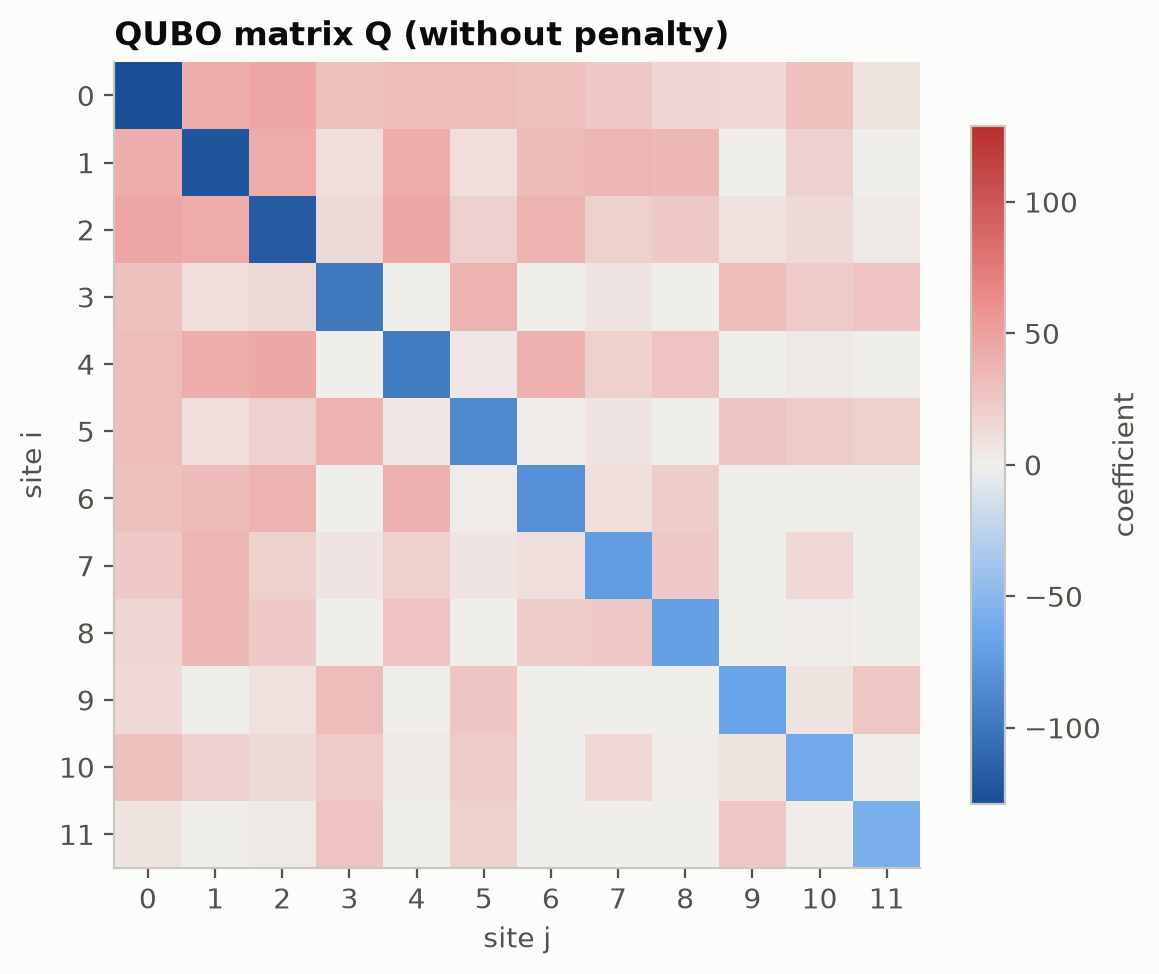

In [6]:
print(f"penalty P = {p.to_qubo()[1] / p.n_select**2:.1f}")
viz.plot_qubo_matrix(p)
plt.show()

**Energy landscape.** All 2﷿﷿﷿ bitstrings ranked by QUBO energy. QAOA succeeds when it
puts most of its sampling probability on the leftmost state. The penalty should push every
infeasible state (wrong number of sites) above the best feasible ones.

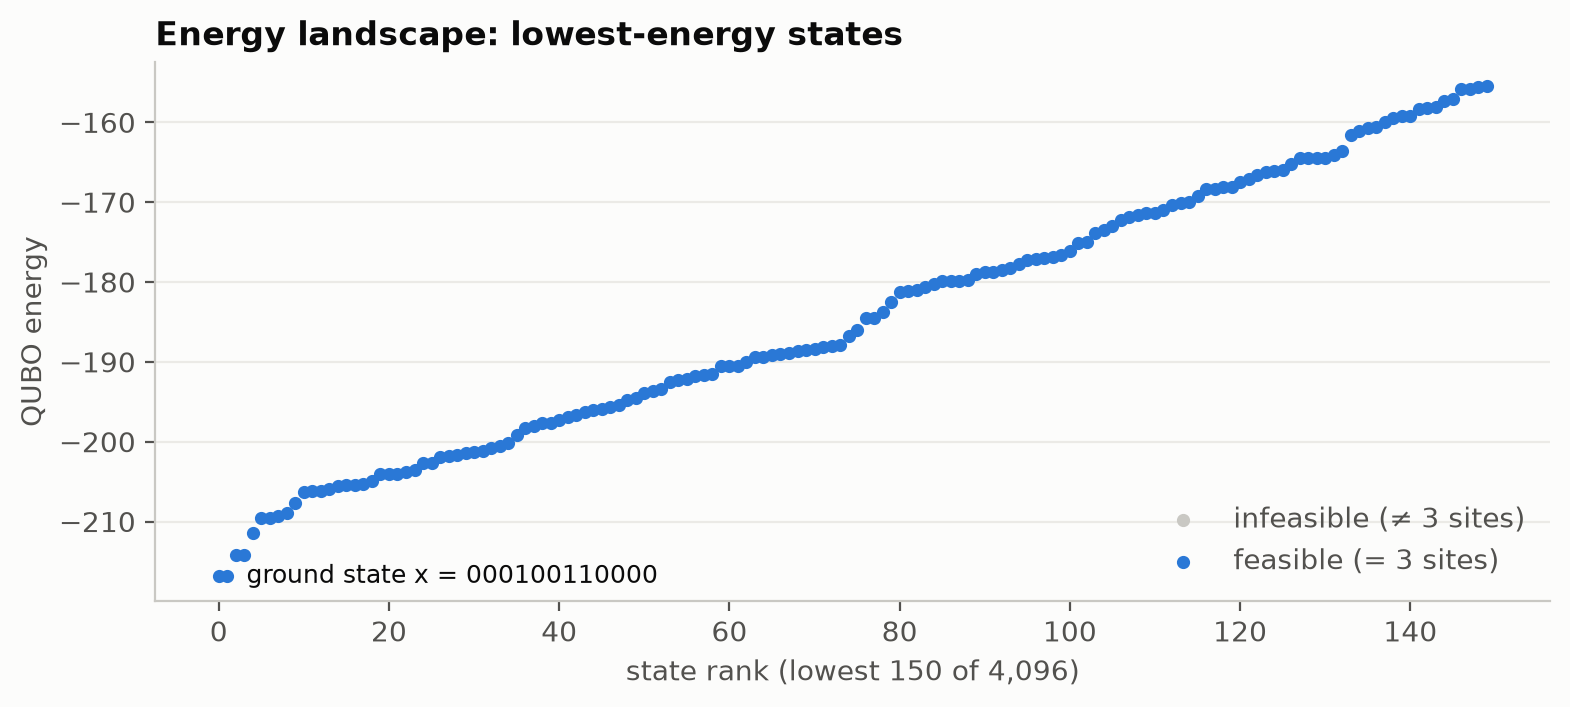

In [7]:
viz.plot_energy_landscape(p, n_lowest=150)
plt.show()

**Approximation quality.** The QUBO counts coverage only up to pairwise overlaps. Each
dot is one feasible selection: points on the diagonal are exact, and points below it
subtract overlap too many times (demand covered by three or more chosen sites).

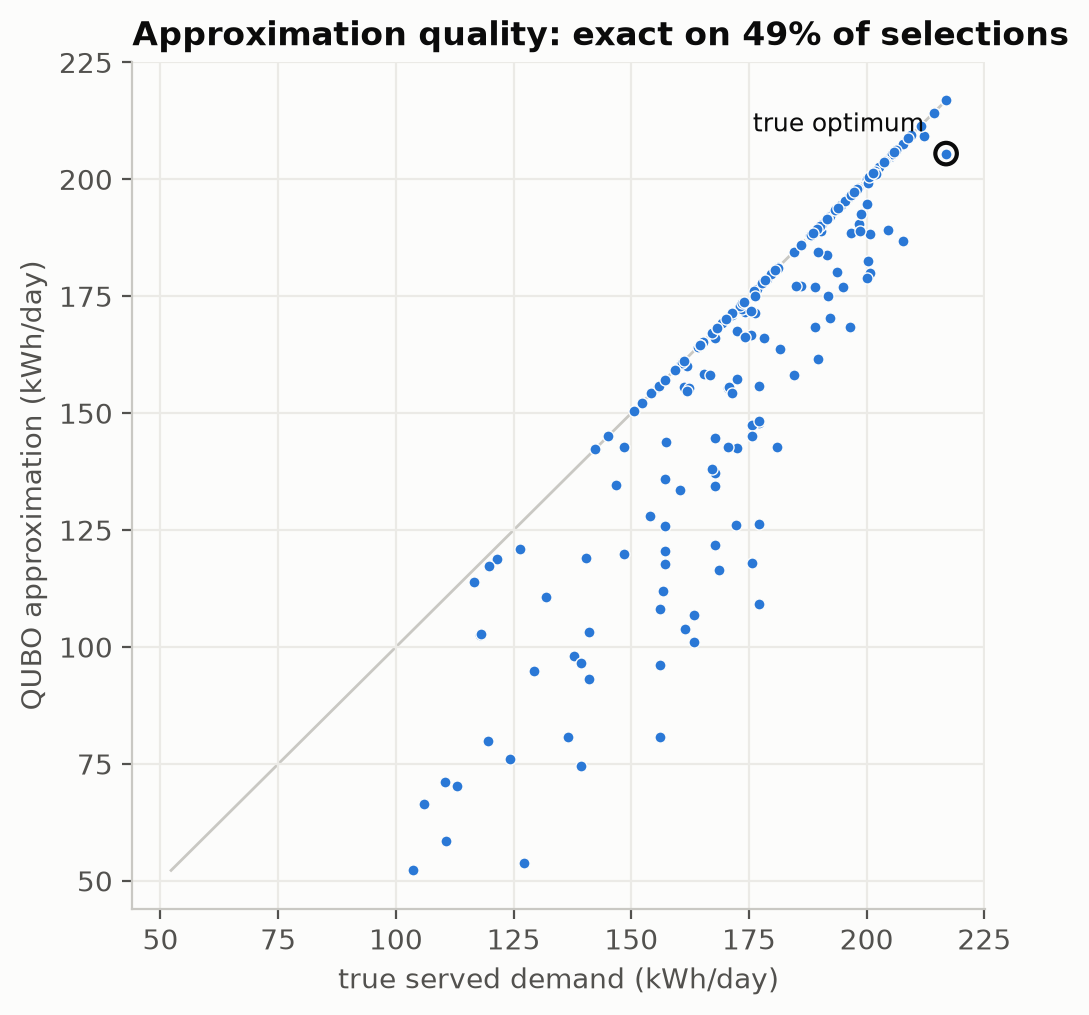

In [8]:
viz.plot_qubo_vs_exact(p)
plt.show()

## 5. Sensitivity to the config

How much of the far-from-grid demand the best selection serves as the number of sites
and the service radius change. When the two lines separate, the QUBO optimum differs
from the true optimum.

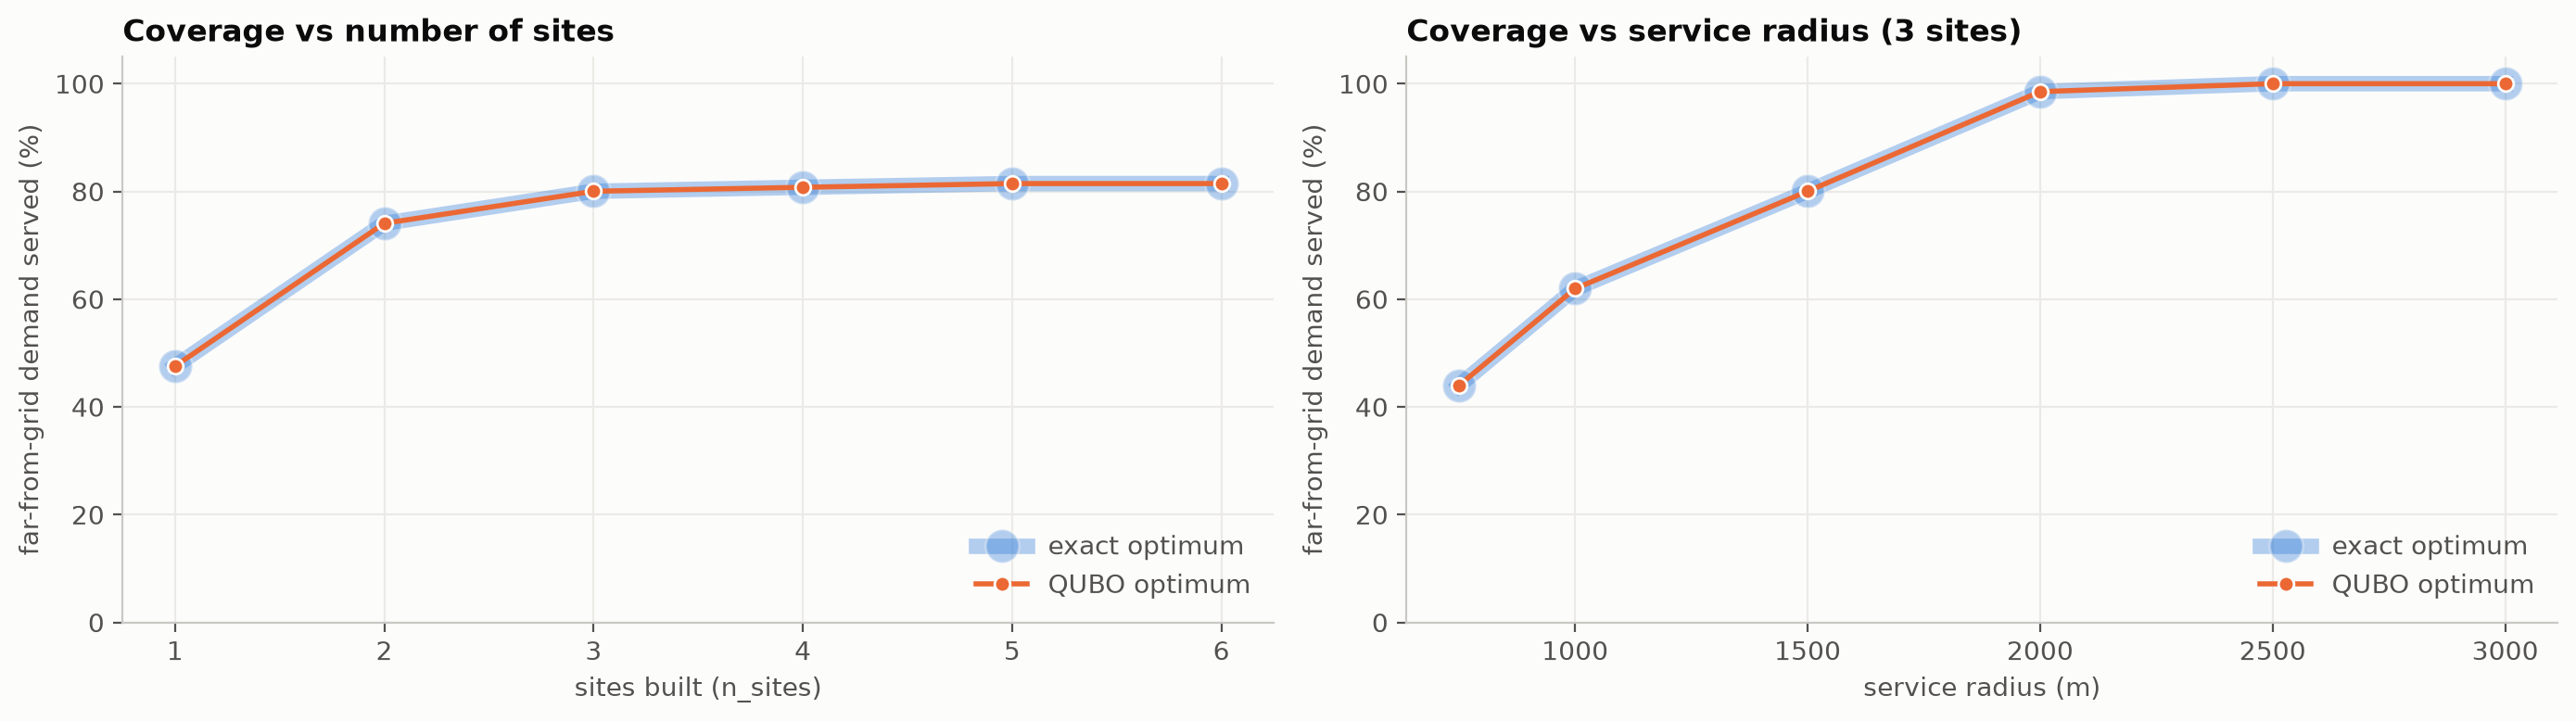

In [9]:
def served_by_both(problem):
    ex = solve_exact(problem)
    qb = solve_qubo_brute_force(*problem.to_qubo())
    return problem.served_demand(ex.x), problem.served_demand(qb.x)

ks = list(range(1, 7))
by_k = np.array([served_by_both(replace(p, n_select=k)) for k in ks])

radii = [750, 1_000, 1_500, 2_000, 2_500, 3_000]
by_r, total_r = [], []
for r in radii:
    pr = build_pilot(replace(cfg, service_radius_m=r)).problem
    by_r.append(served_by_both(pr))
    total_r.append(pr.demand.sum())
by_r = np.array(by_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
viz.plot_sweep(ks, {"exact optimum": by_k[:, 0], "QUBO optimum": by_k[:, 1]}, p.demand.sum(),
               "sites built (n_sites)", "Coverage vs number of sites", ax=axes[0])
viz.plot_sweep(radii, {"exact optimum": by_r[:, 0], "QUBO optimum": by_r[:, 1]}, total_r,
               "service radius (m)", f"Coverage vs service radius ({cfg.n_sites} sites)", ax=axes[1])
plt.tight_layout()
plt.show()

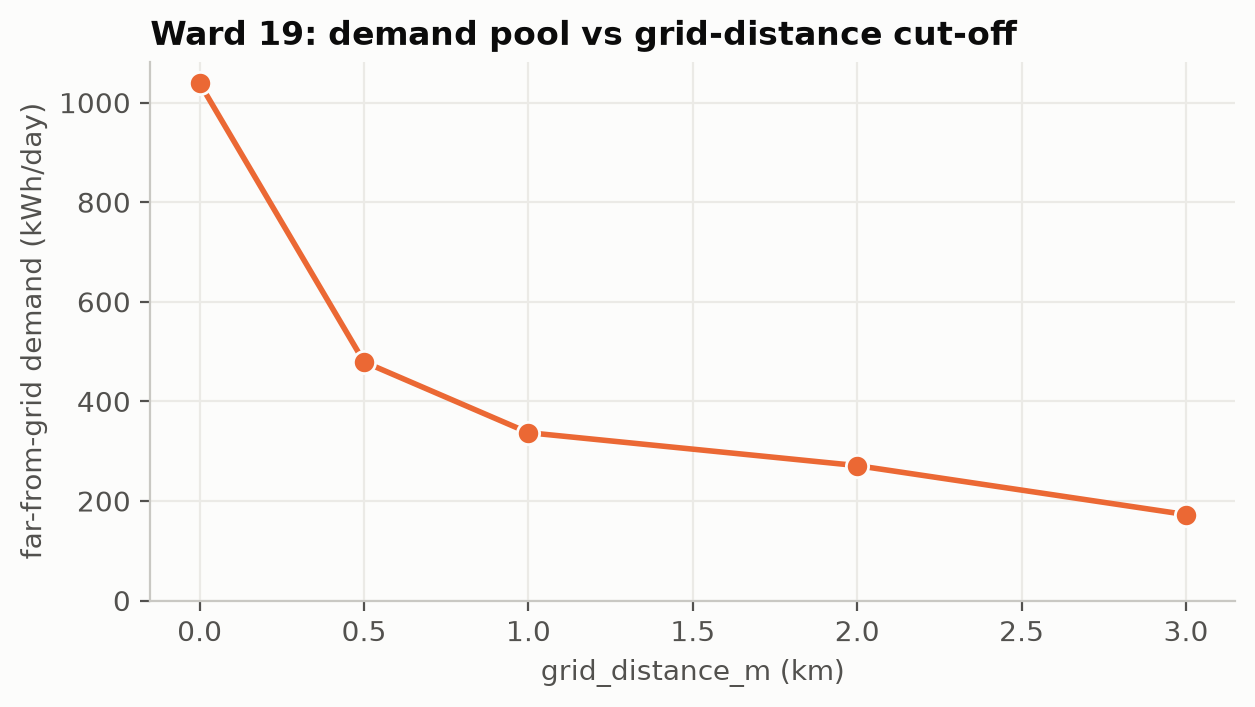

In [10]:
# How the demand pool shrinks as the grid-distance cut-off grows.
distances = [0, 500, 1_000, 2_000, 3_000, 5_000]
pool = []
for d in distances:
    try:
        pool.append(build_pilot(replace(cfg, grid_distance_m=d)).problem.demand.sum())
    except ValueError:  # fewer demand nodes than candidate sites
        pool.append(np.nan)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.array(distances) / 1000, pool, color=viz.UNSERVED, marker="o", markersize=8,
        markeredgecolor=viz.SURFACE)
ax.set_xlabel("grid_distance_m (km)")
ax.set_ylabel("far-from-grid demand (kWh/day)")
ax.set_ylim(bottom=0)
ax.set_title(f"Ward {cfg.ward_no}: demand pool vs grid-distance cut-off")
plt.show()

## 6. QAOA on the local simulator

The QUBO is converted to an Ising Hamiltonian (`x_j = (1 ﷿﷿﷿ Z_j)/2`, one qubit per candidate
site). QAOA alternates the cost Hamiltonian with a mixer, and COBYLA tunes the angles
against Qiskit's `StatevectorEstimator`. The tuned circuit is then sampled with
`StatevectorSampler`.

Two mixers are compared:
- **XY mixer (default):** start in the Dicke state, an equal superposition of every
  selection with exactly K sites, and mix by swapping neighbouring qubits. Every
  measurement is a valid K-site plan, so no penalty is needed.
- **X mixer:** textbook QAOA from `|+﷿﷿﷿﷿﷿﷿`, with K enforced by the QUBO penalty.

Each depth p is seeded from the optimum at p﷿﷿﷿1 (INTERP), so a sweep costs about the same
as a single run at the deepest depth. At 12 qubits, depth 4 takes about 25 s per mixer.

In [11]:
MAX_REPS = 4
sweeps = {mixer: qaoa_depth_sweep(p, MAX_REPS, mixer=mixer) for mixer in ("xy", "x")}
best = sweeps["xy"][-1]
print(f"QAOA (xy, p={best.reps}): x={''.join(map(str, best.x))}  served={p.served_demand(best.x):.1f} kWh/day "
      f"(exact optimum {p.served_demand(exact.x):.1f})")
for mixer, results in sweeps.items():
    for r in results:
        print(f"  {mixer:2s} p={r.reps}: P(opt)={r.p_ground:.3f} ({r.p_ground / r.p_ground_random:.1f}﷿﷿ random)  "
              f"P(feasible)={r.p_feasible:.2f}  approx ratio={r.approximation_ratio:.2f}")

QAOA (xy, p=4): x=011100000000  served=216.9 kWh/day (exact optimum 216.9)
  xy p=1: P(opt)=0.010 (2.2﷿﷿ random)  P(feasible)=1.00  approx ratio=0.80
  xy p=2: P(opt)=0.015 (3.2﷿﷿ random)  P(feasible)=1.00  approx ratio=0.82
  xy p=3: P(opt)=0.024 (5.3﷿﷿ random)  P(feasible)=1.00  approx ratio=0.85
  xy p=4: P(opt)=0.030 (6.6﷿﷿ random)  P(feasible)=1.00  approx ratio=0.86
  x  p=1: P(opt)=0.002 (8.6﷿﷿ random)  P(feasible)=0.41  approx ratio=-3.38
  x  p=2: P(opt)=0.003 (11.5﷿﷿ random)  P(feasible)=0.56  approx ratio=0.18
  x  p=3: P(opt)=0.004 (14.9﷿﷿ random)  P(feasible)=0.73  approx ratio=0.40
  x  p=4: P(opt)=0.004 (17.2﷿﷿ random)  P(feasible)=0.81  approx ratio=0.51


**The circuit.** Depth 1 with the XY mixer: Dicke-state preparation, the cost layer
(RZ and RZZ rotations), then XY swaps around the ring.

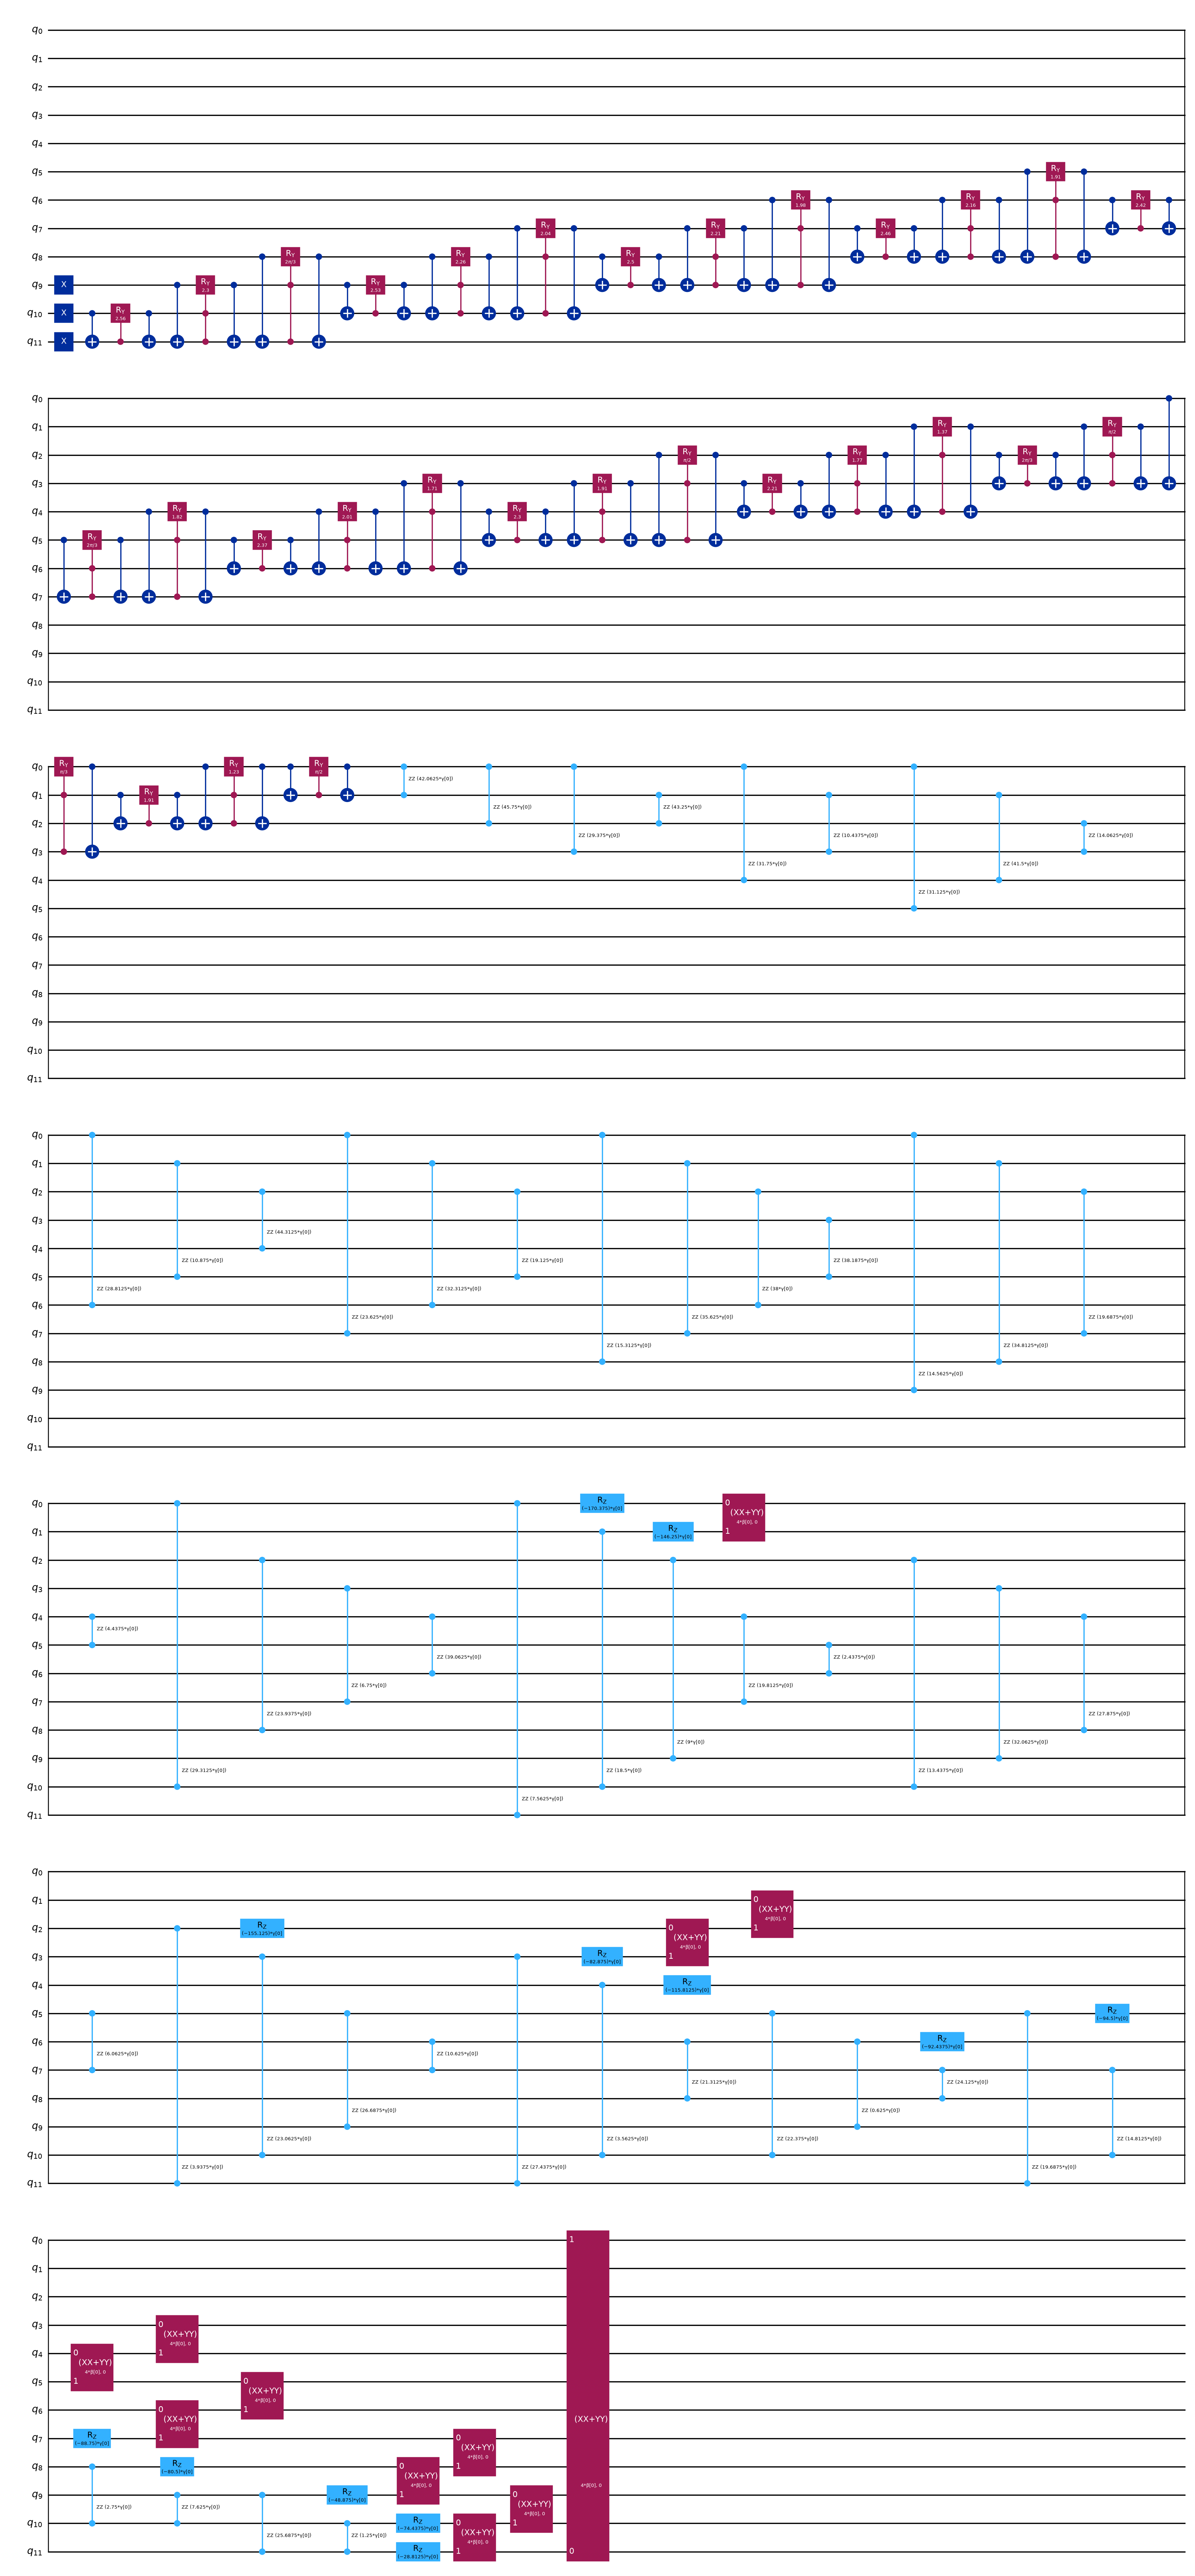

In [12]:
h, _ = qubo_to_ising(*p.to_qubo(0.0))
qaoa_circuit(h, reps=1, mixer="xy", n_select=p.n_select).draw("mpl", fold=40, scale=0.6)

**Where the probability goes.** Feasible selections ranked from best to worse energy.
Bars above the dashed line are sampled more often than a random guess would pick them.

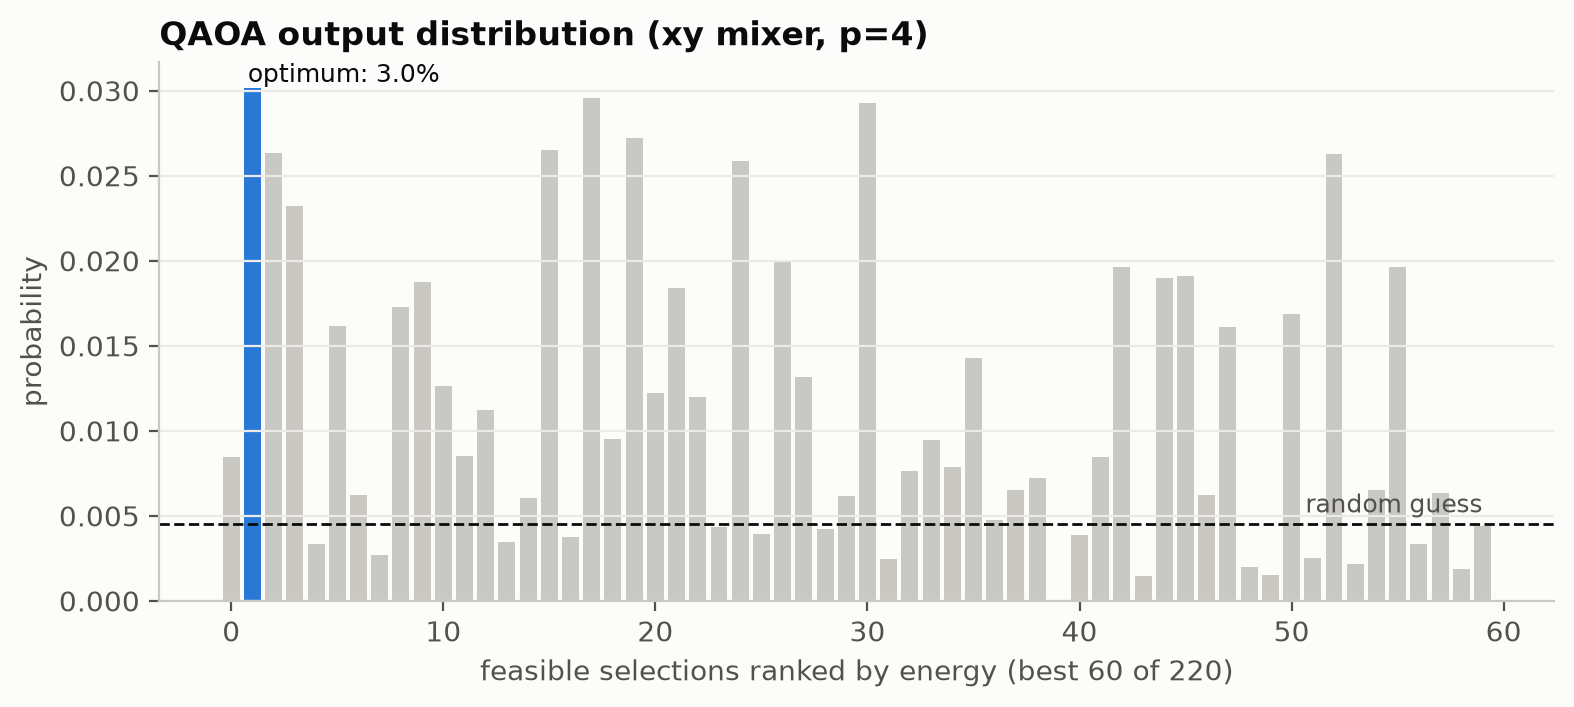

In [13]:
viz.plot_qaoa_distribution(best)
plt.show()

**Depth and mixer.** P(optimum) against each mixer's random-guess baseline (dashed), and the approximation
ratio: 1 means the expected energy equals the optimum, 0 means it equals the worst
feasible plan, and below 0 means probability is sitting on infeasible states. The X
mixer's random baseline is 1/2﷿﷿﷿, the XY mixer's is 1/C(n, K).

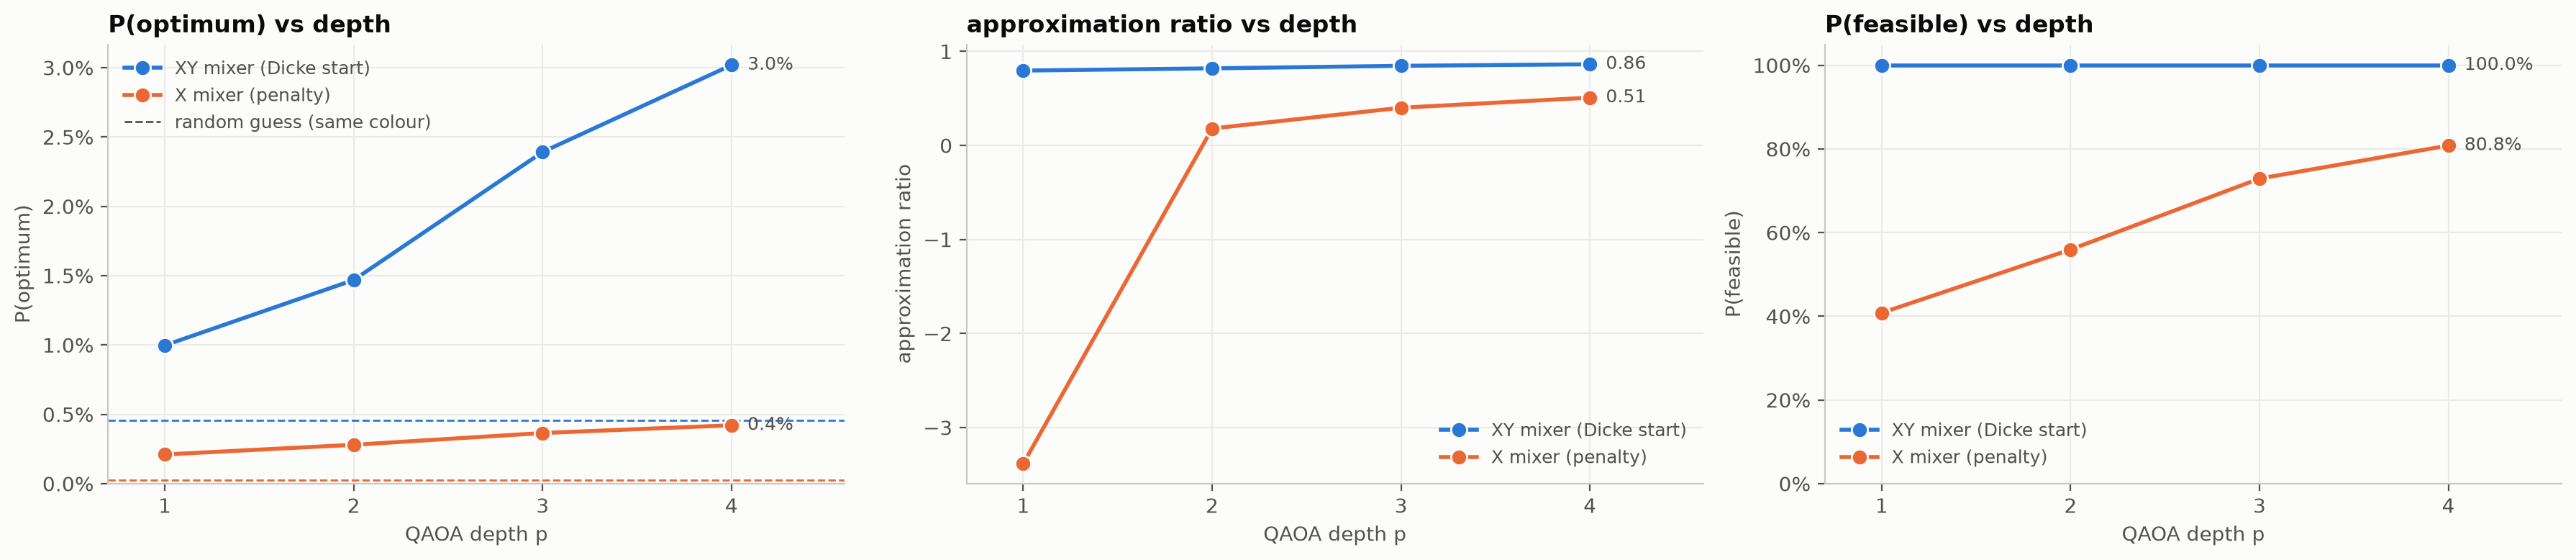

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
viz.plot_depth_sweep(sweeps, "p_ground", ax=axes[0])
viz.plot_depth_sweep(sweeps, "approximation_ratio", ax=axes[1])
viz.plot_depth_sweep(sweeps, "p_feasible", ax=axes[2])
plt.tight_layout()
plt.show()

/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


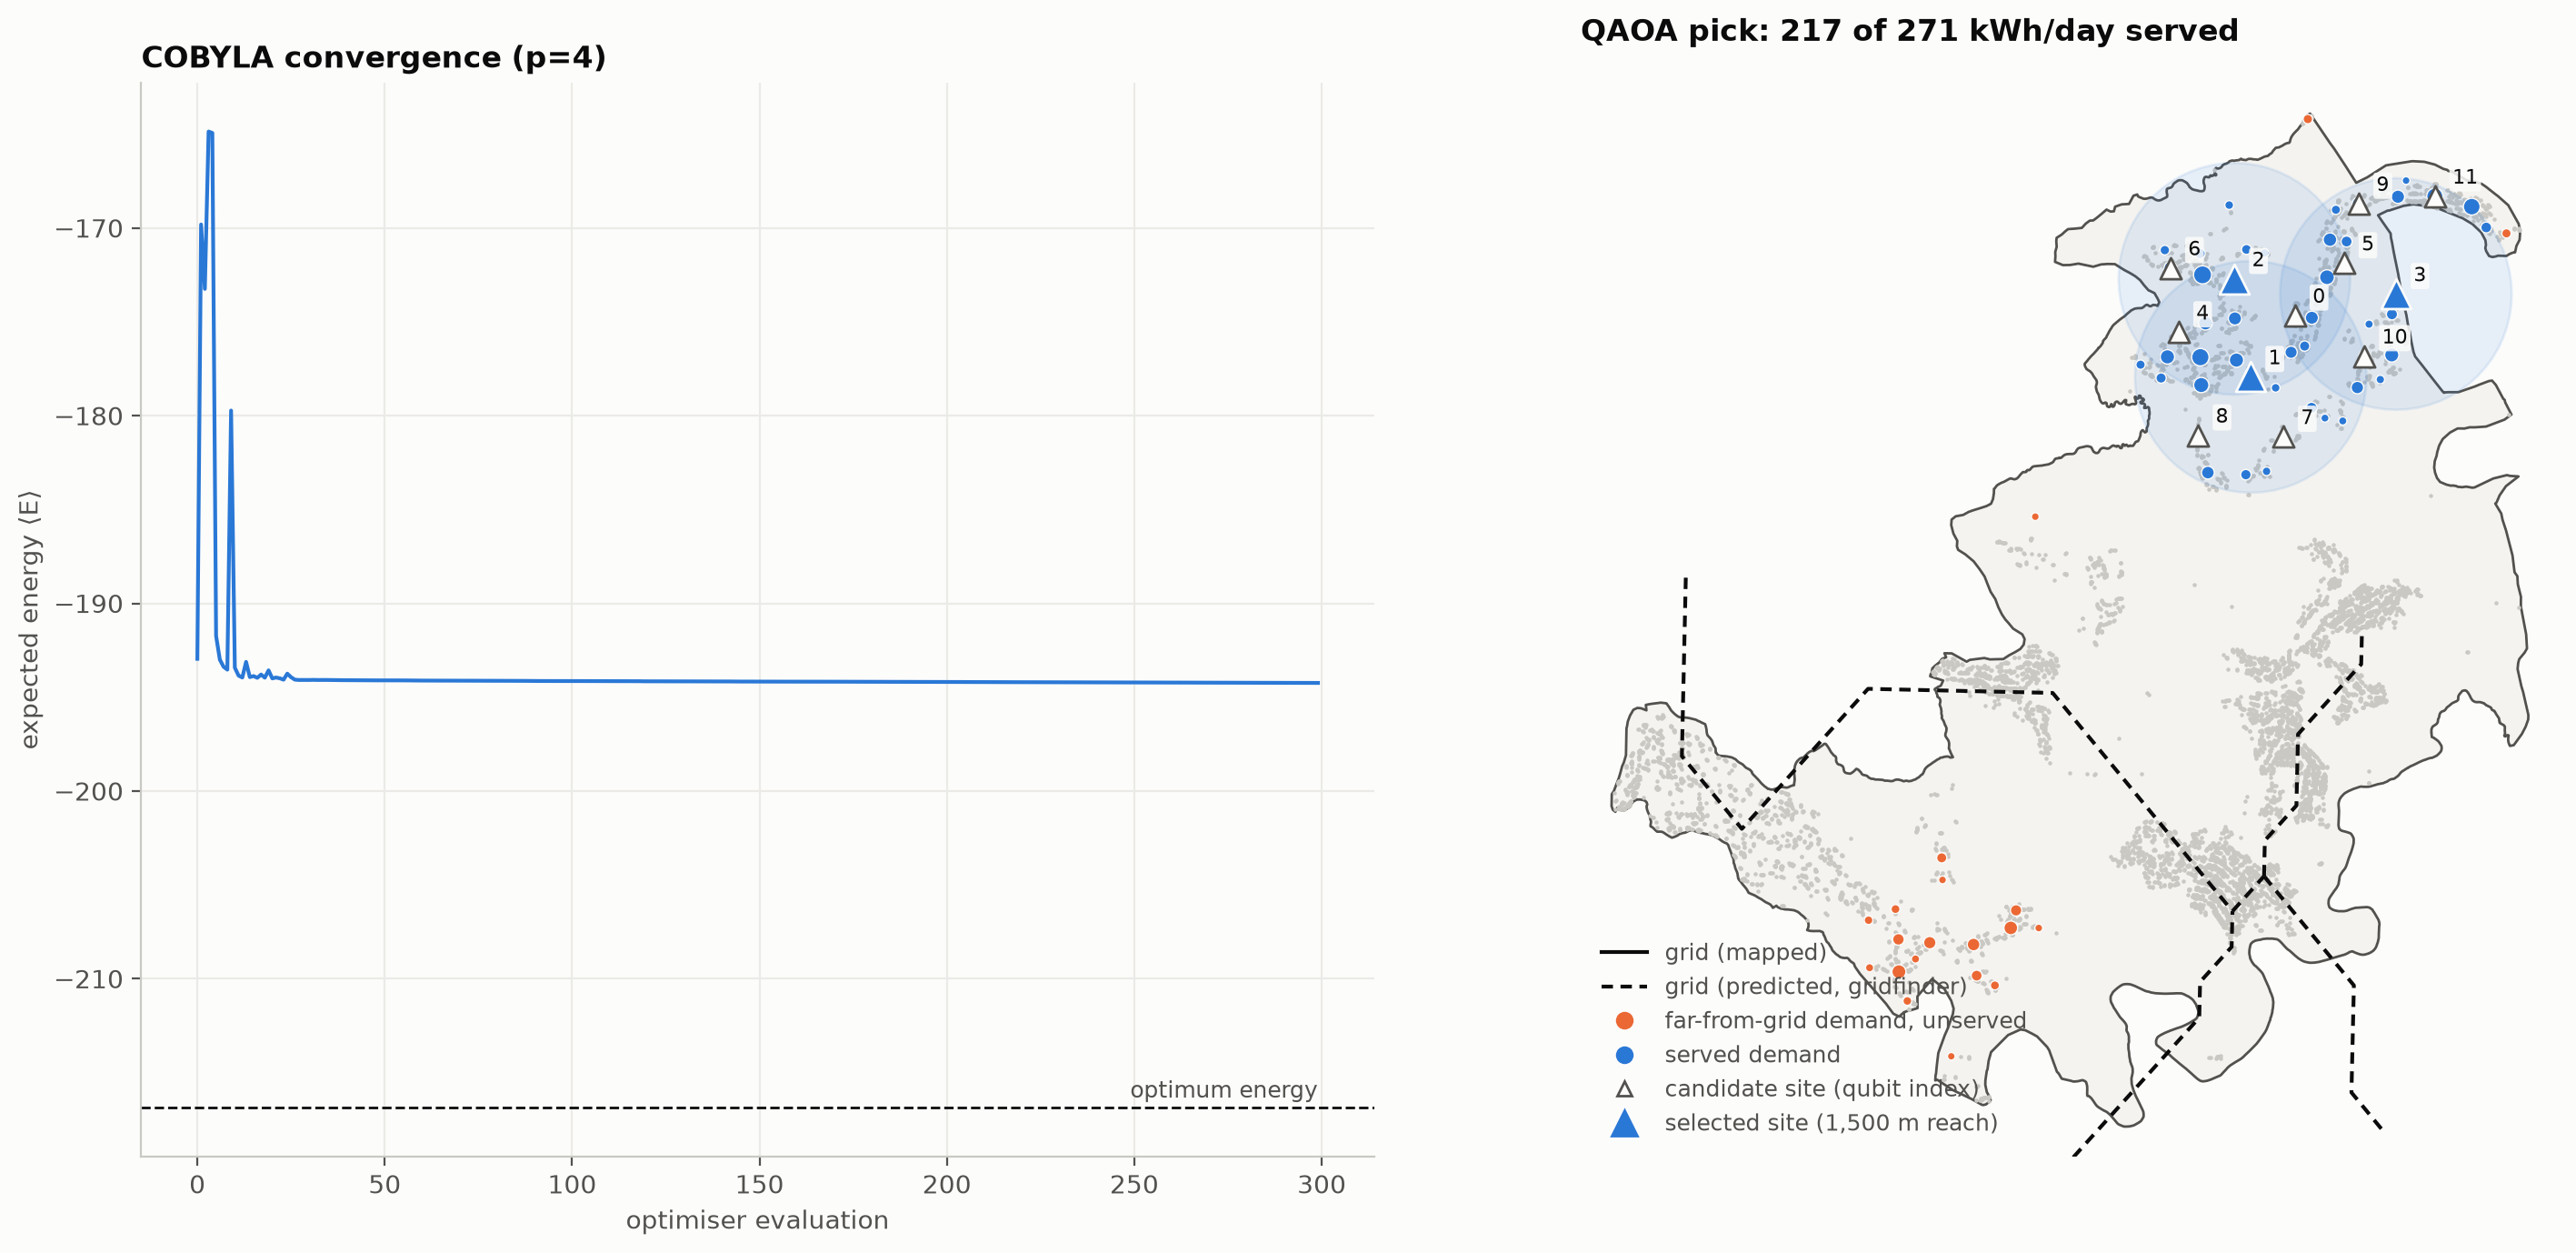

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.3]})
viz.plot_convergence(best, ax=axes[0])
viz.plot_pilot(pilot, best.x, ax=axes[1],
               title=f"QAOA pick: {p.served_demand(best.x):.0f} of {p.demand.sum():.0f} kWh/day served")
plt.tight_layout()
plt.show()

**Toy sub-model.** If a bigger problem gets too slow to simulate, reduce
`n_candidates`: every doubling of simulation cost adds one qubit. At 8 candidate sites
QAOA does noticeably better relative to random guessing, because there are fewer
feasible plans to spread probability over.

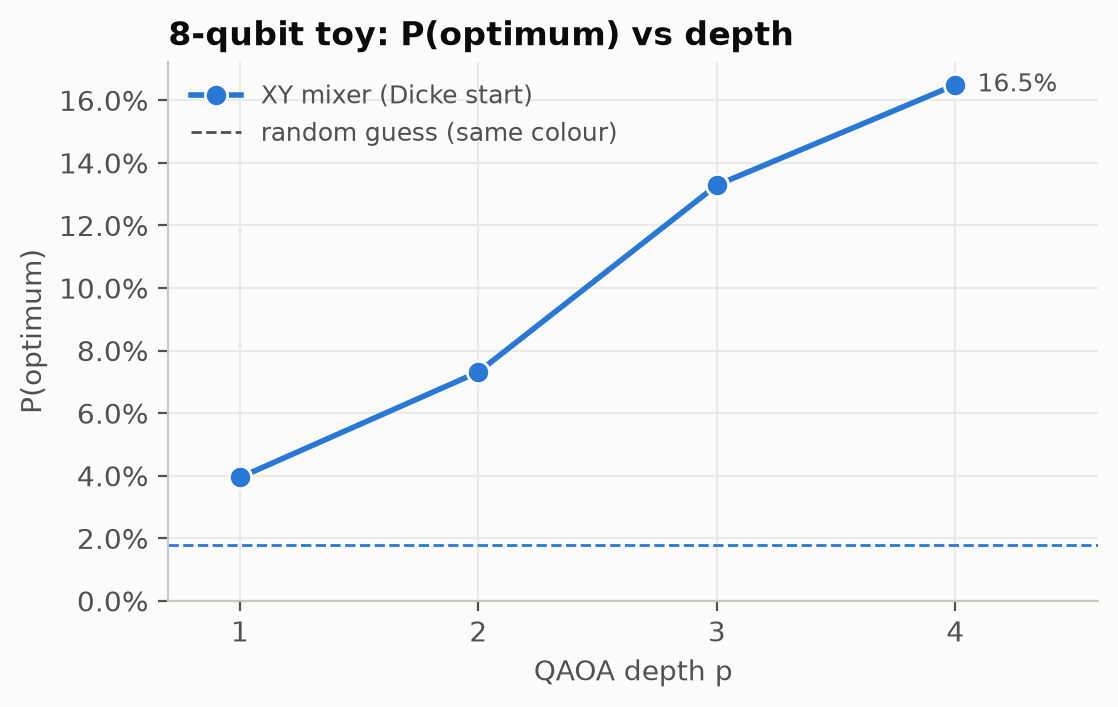

In [16]:
toy = build_pilot(replace(cfg, n_candidates=8)).problem
toy_sweep = {"xy": qaoa_depth_sweep(toy, MAX_REPS, mixer="xy")}
viz.plot_depth_sweep(toy_sweep, "p_ground")
plt.title("8-qubit toy: P(optimum) vs depth", loc="left")
plt.show()

## 7. Running on IBM Quantum hardware

The angles tuned on the simulator are reused, and only the sampling runs on the device.
`BACKEND = "fake_torino"` is a local simulation with IBM Torino's calibrated noise model
(no account needed). Change it to `"least_busy"` or a device name such as
`"ibm_torino"` to submit a real job; see the README for authentication. The circuit is
the 8-qubit toy at depth 1, which is about 280 two-qubit gates after transpilation.

In [17]:
from quackathon.hardware import run_on_backend
from quackathon.quantum import solve_qaoa

BACKEND = "fake_torino"
toy_qaoa = solve_qaoa(toy, reps=1)
hw = run_on_backend(toy, toy_qaoa, BACKEND, shots=4096)
print(f"{hw.backend}: {hw.two_qubit_gates} two-qubit gates, depth {hw.depth}")
print(f"  ideal simulator: P(optimum)={toy_qaoa.p_ground:.3f}  P(feasible)={toy_qaoa.p_feasible:.2f}")
print(f"  {hw.backend:15s}: P(optimum)={hw.p_ground:.3f}  P(feasible)={hw.p_feasible:.2f}  "
      f"(random valid plan {toy_qaoa.p_ground_random:.3f})")
print(f"  best valid sample serves {toy.served_demand(hw.x):.0f} kWh/day (optimum {toy.served_demand(solve_exact(toy).x):.0f})")

Submitted job 4ca9614f-1be7-4dc6-ad82-83a3fb60e539 to fake_torino; waiting for results...
fake_torino: 337 two-qubit gates, depth 788
  ideal simulator: P(optimum)=0.039  P(feasible)=1.00
  fake_torino    : P(optimum)=0.013  P(feasible)=0.43  (random valid plan 0.018)
  best valid sample serves 217 kWh/day (optimum 217)
